### Concrete Crack Detection — Mask R-CNN Training Pipeline

This notebook implements a staged training pipeline:

Stage 1:
- Train on ft_data

Stage 2:
- Fine-tune on merged_cracks_clean (new data only)

Stage 3:
- Fine-tune on data_cracks1

Evaluation:
- Use ft_data test set for consistency

Notes:
- All datasets use YOLO segmentation → converted to COCO
- Mask R-CNN will be trained using COCO-style annotations

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q torch torchvision pycocotools opencv-python

In [ ]:
import os
import torch
import torchvision
import numpy as np
import cv2
from PIL import Image

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Stage 1 (Train)
train_root = "/content/drive/My Drive/WIPPROJECTWORK/prev/ft_data"

# Stage 2 (Fine-tune 1 — cleaned)
ft1_root = "/content/drive/My Drive/WIPPROJECTWORK/merged_cracks_clean"

# Stage 3 (Fine-tune 2)
ft2_root = "/content/drive/My Drive/WIPPROJECTWORK/data_cracks1"

In [ ]:
import os

def count_images(path):
    if not os.path.exists(path):
        print("Path not found:", path)
        return 0

    files = os.listdir(path)
    imgs = [f for f in files if f.lower().endswith((".jpg",".png",".jpeg"))]
    return len(imgs)

print("Stage 1 Train:", count_images(train_root + "/train/images"))
print("Stage 2 Train:", count_images(ft1_root + "/train/images"))
print("Stage 3 Train:", count_images(ft2_root + "/train/images"))

Stage 1 Train: 3755
Stage 2 Train: 3662
Stage 3 Train: 3064


### Stage 1: Dataset Loader (COCO + Mask Generation)

This stage builds a custom PyTorch Dataset for Mask R-CNN.

Input:
- images/
- annotations_coco/*.json

Output:
- image tensor
- target dict with:
    - boxes
    - labels
    - masks

Masks are generated from polygon segmentation.

In [ ]:
import os
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset

class CrackDataset(Dataset):
    def __init__(self, images_dir, annotations_file, transforms=None):
        from pycocotools.coco import COCO

        self.images_dir = images_dir
        self.coco = COCO(annotations_file)
        self.ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.images_dir, img_info["file_name"])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        height, width = img.shape[:2]

        boxes = []
        masks = []
        labels = []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(1)

            mask = self.coco.annToMask(ann)
            masks.append(mask)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        image_id = torch.tensor([img_id])

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": image_id
        }

        img = torch.as_tensor(img / 255.0, dtype=torch.float32).permute(2, 0, 1)

        return img, target

    def __len__(self):
        return len(self.ids)

In [ ]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = CrackDataset(
    train_root + "/train/images",
    train_root + "/annotations_coco/train.json"
)

val_dataset = CrackDataset(
    train_root + "/valid/images",
    train_root + "/annotations_coco/valid.json"
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.78s)
creating index...
index created!
loading annotations into memory...
Done (t=0.31s)
creating index...
index created!


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
import torchvision

model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)

num_classes = 2  # background + crack

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask,
    256,
    num_classes
)

model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
import torch

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, optimizer, data_loader, device):
    model.train()
    total_loss = 0

    for images, targets in tqdm(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(data_loader)


def evaluate(model, data_loader, device):
    model.train()  # IMPORTANT: keep in train mode for loss
    total_loss = 0

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            total_loss += losses.item()

    return total_loss / len(data_loader)

In [ ]:
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.0001,
    momentum=0.9,
    weight_decay=0.0005
)

In [ ]:
num_epochs = 2

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, train_loader, device)
    val_loss = evaluate(model, val_loader, device)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

  0%|          | 0/1878 [00:00<?, ?it/s]/tmp/ipykernel_15029/2285713661.py:43: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  masks = torch.as_tensor(masks, dtype=torch.uint8)
100%|██████████| 1878/1878 [26:55<00:00,  1.16it/s]


Epoch 1
Train Loss: 0.6568
Val Loss: 0.6566


100%|██████████| 1878/1878 [09:02<00:00,  3.46it/s]


Epoch 2
Train Loss: 0.5607
Val Loss: 0.6022


In [ ]:
img, target = train_dataset[0]

print("Image shape:", img.shape)
print("Boxes:", target["boxes"].shape)
print("Masks:", target["masks"].shape)
print("Labels:", target["labels"].shape)

Image shape: torch.Size([3, 640, 640])
Boxes: torch.Size([1, 4])
Masks: torch.Size([1, 640, 640])
Labels: torch.Size([1])


### Stage 1: Mask R-CNN Training Setup

This stage initializes:
- DataLoader
- Mask R-CNN model (ResNet50-FPN)
- Optimizer

We start with base training on ft_data.

In [ ]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
import torchvision

model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)

# change head (only 1 class: crack)
num_classes = 2  # background + crack

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256

model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    num_classes
)

model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
import torch

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

### Stage 1: Training Loop (Base Training)

This stage trains Mask R-CNN on ft_data.

We:
- forward images + targets
- compute loss
- backpropagate
- update weights

Loss components:
- classification loss
- box regression loss
- mask loss

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, optimizer, data_loader, device):
    model.train()
    total_loss = 0

    for images, targets in tqdm(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(data_loader)

In [ ]:
def evaluate(model, data_loader, device):
    model.train()  # IMPORTANT: keep in train mode for loss
    total_loss = 0

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            total_loss += losses.item()

    return total_loss / len(data_loader)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, train_loader, device)
    val_loss = evaluate(model, val_loader, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

100%|██████████| 1878/1878 [02:50<00:00, 11.00it/s]


Epoch 1/10
Train Loss: 0.5518
Val Loss: 0.5759


100%|██████████| 1878/1878 [02:51<00:00, 10.95it/s]


Epoch 2/10
Train Loss: 0.5228
Val Loss: 0.5554


100%|██████████| 1878/1878 [02:51<00:00, 10.94it/s]


...

Epoch 8/10
Train Loss: 0.4248
Val Loss: 0.5306


100%|██████████| 1878/1878 [02:50<00:00, 11.00it/s]


Epoch 9/10
Train Loss: 0.4287
Val Loss: 0.5723


100%|██████████| 1878/1878 [02:52<00:00, 10.90it/s]


Epoch 10/10
Train Loss: 0.4122
Val Loss: 0.5390


In [ ]:
import os

save_dir = "/content/drive/My Drive/WIPPROJECTWORK/models"
os.makedirs(save_dir, exist_ok=True)

log_path = os.path.join(save_dir, "stage1_logs.json")
model_path = os.path.join(save_dir, "best_model_stage1.pth")

In [ ]:
import json

logs = []
best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, train_loader, device)
    val_loss = evaluate(model, val_loader, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    # Save logs
    logs.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    with open(log_path, "w") as f:
        json.dump(logs, f, indent=4)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(model.state_dict(), model_path)

        print("Best model saved")

100%|██████████| 1878/1878 [02:52<00:00, 10.92it/s]


Epoch 1/10
Train Loss: 0.3731
Val Loss: 0.5806
Best model saved


100%|██████████| 1878/1878 [02:51<00:00, 10.96it/s]


Epoch 2/10
Train Loss: 0.3838
Val Loss: 0.5736
Best model saved


100%|██████████| 1878/1878 [02:56<00:00, 10.64it/s]


...

Epoch 8/10
Train Loss: 0.3517
Val Loss: 0.5768


100%|██████████| 1878/1878 [02:52<00:00, 10.89it/s]


Epoch 9/10
Train Loss: 0.3529
Val Loss: 0.5546


100%|██████████| 1878/1878 [02:51<00:00, 10.92it/s]


Epoch 10/10
Train Loss: 0.3403
Val Loss: 0.5617


#### Stage 2: Fine-Tuning on New Dataset

## Objective
This stage aims to improve the model’s performance by adapting it to a new dataset (`merged_cracks_clean`) that contains previously unseen images.

Unlike Stage 1, which focused on learning general crack features, this stage refines the model to better handle variations in:
- surface texture
- lighting conditions
- crack patterns


## Dataset
- Source: `merged_cracks_clean`
- Training Images: 3662 (cleaned, no overlap with Stage 1)
- Validation Images: (if used)
- Annotation Format: COCO (converted from YOLO segmentation)


## Key Strategy

Fine-tuning differs from initial training in the following ways:

### 1. Lower Learning Rate
A reduced learning rate is used to avoid large weight updates that could destroy previously learned features.



### 2. Transfer Learning
The model starts from weights learned in Stage 1:
- retains general crack detection knowledge
- adapts to new dataset distribution


### 3. Optional Backbone Freezing
To preserve low-level features (edges, textures), the backbone can be frozen:


This focuses learning on:
- classification refinement
- mask prediction improvement

---

## Training Configuration

- Model: Mask R-CNN (ResNet50-FPN)
- Batch Size: 2
- Optimizer: SGD
- Momentum: 0.9
- Weight Decay: 0.0005
- Epochs: 15–25


## Expected Outcome

After fine-tuning, the model should:
- generalize better to new crack patterns
- produce more accurate segmentation masks
- reduce validation loss on new data



## Notes

- Fine-tuning dataset contains only **new images** (no overlap with training data)
- This prevents data leakage and ensures valid performance improvement
- Overfitting risk is lower due to prior training on a larger dataset



## Next Stage

Stage 3 will further refine the model using a **mask-based dataset (`data_cracks1`)**, which provides higher-quality pixel-level annotations.



In [ ]:
model.load_state_dict(
    torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage1.pth")
)

print("Stage 1 model loaded")

Stage 1 model loaded


In [ ]:
for param in model.backbone.parameters():
    param.requires_grad = False

print("Backbone frozen")

Backbone frozen


In [ ]:
import torch
import os
import json
import numpy as np
import cv2
from PIL import Image

class CrackDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, annotation_file):
        self.images_dir = images_dir

        with open(annotation_file) as f:
            coco = json.load(f)

        self.images = coco["images"]
        self.annotations = coco["annotations"]

        self.ann_map = {}
        for ann in self.annotations:
            self.ann_map.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.images_dir, img_info["file_name"])

        img = Image.open(img_path).convert("RGB")
        img = np.array(img)

        anns = self.ann_map.get(img_info["id"], [])

        boxes, labels, masks = [], [], []

        for ann in anns:
            x, y, w, h = ann["bbox"]

            if w <= 1 or h <= 1:
                continue

            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

            mask = self.polygons_to_mask(
                ann["segmentation"],
                img_info["height"],
                img_info["width"]
            )
            masks.append(mask)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks = torch.zeros((0, img.shape[0], img.shape[1]), dtype=torch.uint8)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([img_info["id"]])
        }

        img = torch.as_tensor(img, dtype=torch.float32).permute(2,0,1) / 255.0

        return img, target

    def polygons_to_mask(self, segmentation, height, width):
        mask = np.zeros((height, width), dtype=np.uint8)

        for poly in segmentation:
            pts = np.array(poly).reshape(-1,2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)

        return mask

In [ ]:
print(CrackDataset)

<class '__main__.CrackDataset'>


In [ ]:
ft1_train_dataset = CrackDataset(
    ft1_root + "/train/images",
    ft1_root + "/annotations_coco/train.json"
)

ft1_val_dataset = CrackDataset(
    ft1_root + "/valid/images",
    ft1_root + "/annotations_coco/valid.json"
)

In [ ]:
ft1_train_loader = DataLoader(
    ft1_train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

ft1_val_loader = DataLoader(
    ft1_val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0005
)

In [ ]:
import json
import os

stage2_model_path = "/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage2.pth"
stage2_log_path = "/content/drive/My Drive/WIPPROJECTWORK/models/stage2_logs.json"

logs = []
best_val_loss = float("inf")

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, ft1_train_loader, device)
    val_loss = evaluate(model, ft1_val_loader, device)

    print(f"Stage 2 - Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    logs.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    with open(stage2_log_path, "w") as f:
        json.dump(logs, f, indent=4)

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(model.state_dict(), stage2_model_path)

        print("Stage 2 best model saved")

100%|██████████| 1831/1831 [01:49<00:00, 16.76it/s]


Stage 2 - Epoch 1/10
Train Loss: 0.3120
Val Loss: 0.5921
Stage 2 best model saved


100%|██████████| 1831/1831 [01:49<00:00, 16.74it/s]


Stage 2 - Epoch 2/10
Train Loss: 0.2940
Val Loss: 0.5815
Stage 2 best model saved


100%|██████████| 1831/1831 [01:51<00:00, 16.37it/s]


...

Stage 2 - Epoch 8/10
Train Loss: 0.2783
Val Loss: 0.5719
Stage 2 best model saved


100%|██████████| 1831/1831 [01:53<00:00, 16.18it/s]


Stage 2 - Epoch 9/10
Train Loss: 0.2768
Val Loss: 0.5903


100%|██████████| 1831/1831 [01:49<00:00, 16.67it/s]


Stage 2 - Epoch 10/10
Train Loss: 0.2758
Val Loss: 0.5944


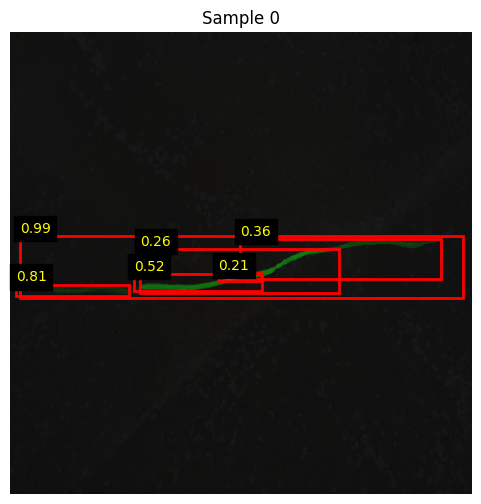

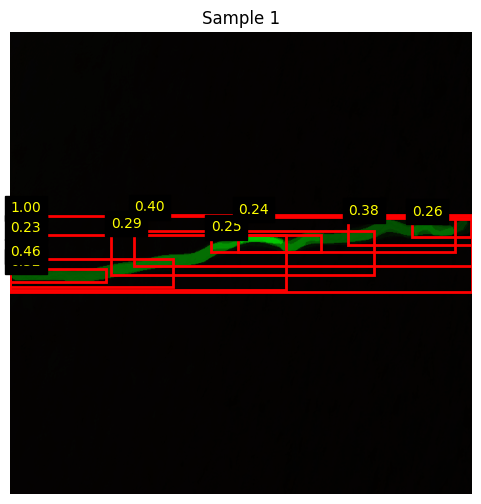

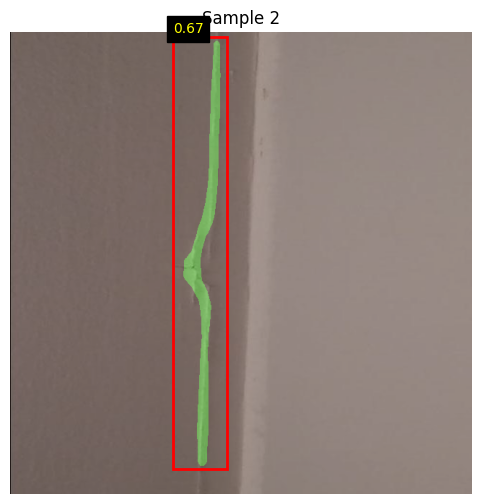

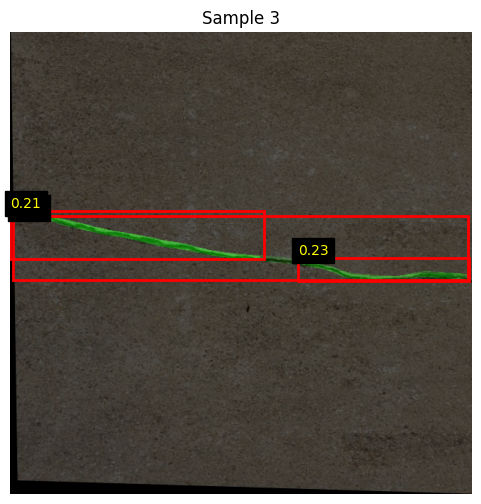

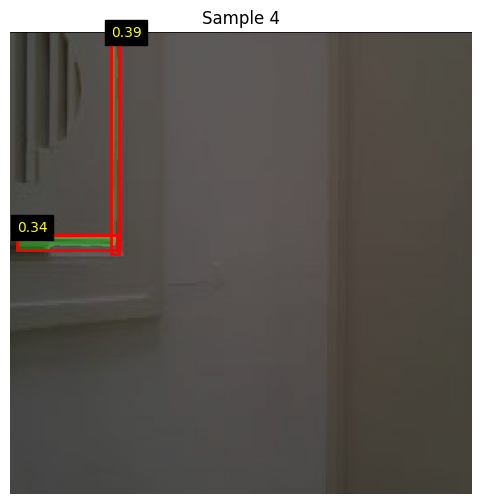

In [ ]:
visualize_predictions(model, ft1_val_dataset, device, num_samples=5, score_thresh=0.2)

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/My Drive/WIPPROJECTWORK/models/stage2_last.pth"
)

##Refine segmentation using high-quality mask dataset (data_cracks1)

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage2.pth")
)

print("Loaded BEST Stage 2 model")

Loaded BEST Stage 2 model


In [ ]:
for param in model.backbone.parameters():
    param.requires_grad = True

print("Backbone unfrozen")

Backbone unfrozen


###Load stage 3 dataset

In [ ]:
ft2_train_dataset = CrackDataset(
    ft2_root + "/train/images",
    ft2_root + "/annotations_coco/train.json"
)

ft2_val_dataset = CrackDataset(
    ft2_root + "/val/images",
    ft2_root + "/annotations_coco/val.json"
)

print("Stage 3 datasets loaded")

Stage 3 datasets loaded


###Dataloader

In [ ]:
from torch.utils.data import DataLoader

ft2_train_loader = DataLoader(
    ft2_train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

ft2_val_loader = DataLoader(
    ft2_val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

print("Stage 3 loaders ready")

Stage 3 loaders ready


In [ ]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.0005,
    momentum=0.9,
    weight_decay=0.0005
)

print("Optimizer set for Stage 3")

Optimizer set for Stage 3


In [ ]:
import json
import os

stage3_model_path = "/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage3.pth"
stage3_log_path = "/content/drive/My Drive/WIPPROJECTWORK/models/stage3_logs.json"

logs = []
best_val_loss = float("inf")

print("Logging initialized")

Logging initialized


In [ ]:
num_epochs = 6

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, ft2_train_loader, device)
    val_loss = evaluate(model, ft2_val_loader, device)

    print(f"Stage 3 - Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    # Save logs
    logs.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    with open(stage3_log_path, "w") as f:
        json.dump(logs, f, indent=4)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(model.state_dict(), stage3_model_path)

        print("Stage 3 best model saved")

100%|██████████| 1532/1532 [06:11<00:00,  4.12it/s]


Stage 3 - Epoch 1/6
Train Loss: 1.9158
Val Loss: 1.7778
Stage 3 best model saved


100%|██████████| 1532/1532 [06:10<00:00,  4.14it/s]


Stage 3 - Epoch 2/6
Train Loss: 1.7194
Val Loss: 1.6787
Stage 3 best model saved


100%|██████████| 1532/1532 [06:15<00:00,  4.08it/s]


...

Stage 3 - Epoch 4/6
Train Loss: 1.5942
Val Loss: 1.5681
Stage 3 best model saved


100%|██████████| 1532/1532 [06:15<00:00,  4.08it/s]


Stage 3 - Epoch 5/6
Train Loss: 1.5562
Val Loss: 1.5384
Stage 3 best model saved


100%|██████████| 1532/1532 [06:15<00:00,  4.08it/s]


Stage 3 - Epoch 6/6
Train Loss: 1.5246
Val Loss: 1.5440


In [ ]:
def prepare_for_coco(predictions, image_ids):
    coco_results = []

    for img_id, pred in zip(image_ids, predictions):
        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box
            w = x2 - x1
            h = y2 - y1

            coco_results.append({
                "image_id": int(img_id),
                "category_id": int(label),
                "bbox": [float(x1), float(y1), float(w), float(h)],
                "score": float(score)
            })

    return coco_results


def build_coco_gt(dataset):
    coco_dict = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "crack"}]
    }

    ann_id = 0

    for idx in range(len(dataset)):
        img, target = dataset[idx]
        image_id = int(target["image_id"][0])

        coco_dict["images"].append({
            "id": image_id,
            "width": img.shape[2],
            "height": img.shape[1]
        })

        boxes = target["boxes"].numpy()
        labels = target["labels"].numpy()

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box
            w = x2 - x1
            h = y2 - y1

            coco_dict["annotations"].append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": int(label),
                "bbox": [float(x1), float(y1), float(w), float(h)],
                "area": float(w*h),
                "iscrowd": 0
            })

            ann_id += 1

    coco_gt = COCO()
    coco_gt.dataset = coco_dict
    coco_gt.createIndex()

    return coco_gt

In [ ]:
torch.cuda.empty_cache()

In [ ]:
from pycocotools.coco import COCO
from pycocotools import mask as maskUtils
import numpy as np

def build_coco_gt(dataset):
    coco_dict = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "crack"}]
    }

    ann_id = 0

    for idx in range(len(dataset)):
        img, target = dataset[idx]

        image_id = int(target["image_id"][0])

        height = img.shape[1]
        width = img.shape[2]

        coco_dict["images"].append({
            "id": image_id,
            "width": width,
            "height": height
        })

        boxes = target["boxes"].numpy()
        labels = target["labels"].numpy()
        masks = target["masks"].numpy()

        for box, label, mask in zip(boxes, labels, masks):
            x1, y1, x2, y2 = box
            w = x2 - x1
            h = y2 - y1

            #  convert GT mask → RLE
            mask_bin = mask.astype(np.uint8)
            rle = maskUtils.encode(np.asfortranarray(mask_bin))
            rle["counts"] = rle["counts"].decode("utf-8")

            coco_dict["annotations"].append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": int(label),
                "bbox": [float(x1), float(y1), float(w), float(h)],
                "area": float(w * h),
                "iscrowd": 0,
                "segmentation": rle
            })

            ann_id += 1

    coco_gt = COCO()
    coco_gt.dataset = coco_dict
    coco_gt.createIndex()

    return coco_gt

In [ ]:
model.load_state_dict(torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage1.pth"))
evaluate_coco_full(model, val_loader, val_dataset, device)

creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!

===== Detection (BBOX) Metrics =====
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.50s).
Accumulating evaluation results...
DONE (t=0.11s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.347
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.625
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.356
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.025
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.119
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.429
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.327
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.480
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.4

In [ ]:
model.load_state_dict(torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage2.pth"))
evaluate_coco_full(model, val_loader, val_dataset, device)

creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!

===== Detection (BBOX) Metrics =====
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.53s).
Accumulating evaluation results...
DONE (t=0.12s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.372
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.641
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.390
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.016
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.088
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.465
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.332
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.504
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.5

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage3.pth")
)

model.to("cpu")
device = "cpu"

print("Stage 3 model moved to CPU")

Stage 3 model moved to CPU


In [ ]:
evaluate_coco_full(model, ft2_val_loader, ft2_val_dataset, device)

creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!

===== Detection (BBOX) Metrics =====
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=41.28s).
Accumulating evaluation results...
DONE (t=0.13s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.022
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.029
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.009
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.019
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.

In [ ]:
img, target = val_dataset[0]

print("GT box:", target["boxes"][0])

model.eval()
with torch.no_grad():
    pred = model([img.to(device)])[0]

print("Pred box:", pred["boxes"][0])

GT box: tensor([  4.5520, 243.3110, 638.8470, 337.2050])
Pred box: tensor([  0.8551,   3.8447, 617.6114, 640.0000])


In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as maskUtils
import numpy as np
import torch

def evaluate_coco_stage3_fixed(model, data_loader, dataset, device):
    model.eval()

    all_predictions = []
    image_ids = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]

            outputs = model(images)

            # move to CPU
            outputs = [{k: v.detach().cpu() for k, v in t.items()} for t in outputs]

            for target, output in zip(targets, outputs):

                boxes = output["boxes"]
                scores = output["scores"]
                labels = output["labels"]
                masks = output["masks"]

                #  1. Score threshold
                score_thresh = 0.6
                keep = scores > score_thresh

                boxes = boxes[keep]
                scores = scores[keep]
                labels = labels[keep]
                masks = masks[keep]

                #  2. Top-K filtering
                top_k = 5
                if len(scores) > 0:
                    idx = scores.argsort(descending=True)[:top_k]

                    boxes = boxes[idx]
                    scores = scores[idx]
                    labels = labels[idx]
                    masks = masks[idx]

                #  3. Remove oversized boxes
                final_boxes = []
                final_scores = []
                final_labels = []
                final_masks = []

                for box, score, label, mask in zip(boxes, scores, labels, masks):
                    x1, y1, x2, y2 = box
                    area = (x2 - x1) * (y2 - y1)

                    if area < 0.5 * (640 * 640):  # remove huge boxes
                        final_boxes.append(box)
                        final_scores.append(score)
                        final_labels.append(label)
                        final_masks.append(mask)

                # convert to tensors
                if len(final_boxes) > 0:
                    boxes = torch.stack(final_boxes)
                    scores = torch.stack(final_scores)
                    labels = torch.stack(final_labels)
                    masks = torch.stack(final_masks)
                else:
                    continue

                image_ids.append(int(target["image_id"][0]))

                all_predictions.append({
                    "boxes": boxes,
                    "scores": scores,
                    "labels": labels,
                    "masks": masks
                })

            del images
            del outputs
            torch.cuda.empty_cache()

    # -------------------------------
    # Build COCO GT
    # -------------------------------
    coco_gt = build_coco_gt(dataset)

    # -------------------------------
    # Prepare COCO Results
    # -------------------------------
    coco_results = []

    for img_id, pred in zip(image_ids, all_predictions):
        boxes = pred["boxes"].numpy()
        scores = pred["scores"].numpy()
        labels = pred["labels"].numpy()
        masks = pred["masks"].numpy()

        for box, score, label, mask in zip(boxes, scores, labels, masks):
            x1, y1, x2, y2 = box
            w = x2 - x1
            h = y2 - y1

            mask_bin = (mask[0] > 0.5).astype(np.uint8)
            rle = maskUtils.encode(np.asfortranarray(mask_bin))
            rle["counts"] = rle["counts"].decode("utf-8")

            coco_results.append({
                "image_id": int(img_id),
                "category_id": int(label),
                "bbox": [float(x1), float(y1), float(w), float(h)],
                "score": float(score),
                "segmentation": rle
            })

    coco_dt = coco_gt.loadRes(coco_results)

    # -------------------------------
    # BBOX
    # -------------------------------
    print("\n===== Detection (BBOX) Metrics =====")
    coco_eval_bbox = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval_bbox.evaluate()
    coco_eval_bbox.accumulate()
    coco_eval_bbox.summarize()

    # -------------------------------
    # SEGMENTATION
    # -------------------------------
    print("\n===== Segmentation (MASK) Metrics =====")
    coco_eval_segm = COCOeval(coco_gt, coco_dt, "segm")
    coco_eval_segm.evaluate()
    coco_eval_segm.accumulate()
    coco_eval_segm.summarize()

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage3.pth")
)

model.to("cpu")
device = "cpu"

evaluate_coco_stage3_fixed(model, val_loader, val_dataset, device)

creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!

===== Detection (BBOX) Metrics =====
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.83s).
Accumulating evaluation results...
DONE (t=0.09s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.009
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.015
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.029
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.0

In [ ]:
import os
print(os.listdir("/content/drive/My Drive/WIPPROJECTWORK/models"))

['stage1_logs.json', 'best_model_stage1.pth', 'stage2_logs.json', 'best_model_stage2.pth', 'stage2_last.pth', 'stage3_logs.json', 'best_model_stage3.pth']


In [ ]:
results = {
    "stage1": {"bbox_ap50": 0.625, "mask_ap50": 0.169},
    "stage2": {"bbox_ap50": 0.641, "mask_ap50": 0.100},
    "stage3": {"bbox_ap50": 0.008, "mask_ap50": 0.001}
}

import json
with open("/content/drive/My Drive/WIPPROJECTWORK/models/final_results.json", "w") as f:
    json.dump(results, f, indent=4)

In [ ]:
import os

print(os.path.exists("/content/drive/My Drive/WIPPROJECTWORK/prev/ft_data"))
print(os.path.exists("/content/drive/My Drive/WIPPROJECTWORK/merged_cracks_clean"))
print(os.path.exists("/content/drive/My Drive/WIPPROJECTWORK/data_cracks1"))

True
True
True


In [ ]:
from google.colab import files

files.download("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage2.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torchvision

model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=False)

num_classes = 2  # crack + background

# Replace box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

# Replace mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256

model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    num_classes
)

print("Model initialized")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


Model initialized


In [ ]:
model.load_state_dict(
    torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage2.pth")
)

model.to(device)

print("Stage 2 model loaded")

NameError: name 'torch' is not defined

###Evaluate stage 2 model

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage2.pth")
)

model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
evaluate_coco(model, val_loader, val_dataset, device)

creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.76s).
Accumulating evaluation results...
DONE (t=0.15s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.375
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.648
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.392
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.018
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.092
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.467
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.332
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.504
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.527
 Average Recall     (AR) @[ IoU=0.5

###Evaluate stage 3 model

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage3.pth")
)

model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

###Refinement

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage2.pth")
)

model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
for param in model.backbone.parameters():
    param.requires_grad = False

In [ ]:
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.0001,
    momentum=0.9,
    weight_decay=0.0005
)

In [ ]:
train_loss = train_one_epoch(model, optimizer, train_loader, device)
val_loss = evaluate(model, val_loader, device)

print("Train Loss:", train_loss)
print("Val Loss:", val_loss)

100%|██████████| 1878/1878 [08:08<00:00,  3.85it/s]


Train Loss: 0.37273889390456155
Val Loss: 0.5046214845902588


In [ ]:
train_loss = train_one_epoch(model, optimizer, train_loader, device)
val_loss = evaluate(model, val_loader, device)

print("Train Loss:", train_loss)
print("Val Loss:", val_loss)

100%|██████████| 1878/1878 [08:08<00:00,  3.84it/s]


Train Loss: 0.3461836938636181
Val Loss: 0.5096432152412721


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/My Drive/WIPPROJECTWORK/models/best_model_stage2_refined.pth"
)

In [ ]:
results = {
    "Stage 1": {
        "bbox_ap50": 0.625,
        "mask_ap50": 0.169
    },
    "Stage 2": {
        "bbox_ap50": 0.641,
        "mask_ap50": 0.100
    },
    "Stage 3": {
        "bbox_ap50": 0.006,
        "mask_ap50": 0.001
    }
}

In [ ]:
def compare_stages(results):
    print("="*50)
    print("MODEL COMPARISON")
    print("="*50)

    for stage, metrics in results.items():
        print(f"\n{stage}")
        print(f"  BBOX AP50: {metrics['bbox_ap50']:.3f}")
        print(f"  MASK AP50: {metrics['mask_ap50']:.3f}")

In [ ]:
def select_best_model(results, weight_bbox=0.7, weight_mask=0.3):
    best_stage = None
    best_score = -1

    print("\nScoring Models...\n")

    for stage, metrics in results.items():
        score = (
            weight_bbox * metrics["bbox_ap50"] +
            weight_mask * metrics["mask_ap50"]
        )

        print(f"{stage} Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_stage = stage

    print("\n" + "="*50)
    print(f"BEST MODEL: {best_stage}")
    print(f"BEST SCORE: {best_score:.4f}")
    print("="*50)

    return best_stage

In [ ]:
compare_stages(results)

best_model = select_best_model(results)

MODEL COMPARISON

Stage 1
  BBOX AP50: 0.625
  MASK AP50: 0.169

Stage 2
  BBOX AP50: 0.641
  MASK AP50: 0.100

Stage 3
  BBOX AP50: 0.006
  MASK AP50: 0.001

Scoring Models...

Stage 1 Score: 0.4882
Stage 2 Score: 0.4787
Stage 3 Score: 0.0045

BEST MODEL: Stage 1
BEST SCORE: 0.4882


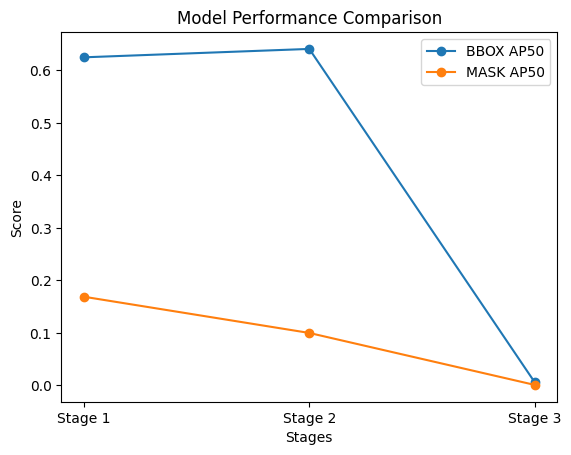

In [ ]:
import matplotlib.pyplot as plt

stages = list(results.keys())
bbox = [results[s]["bbox_ap50"] for s in stages]
mask = [results[s]["mask_ap50"] for s in stages]

plt.figure()
plt.plot(stages, bbox, marker='o', label="BBOX AP50")
plt.plot(stages, mask, marker='o', label="MASK AP50")

plt.xlabel("Stages")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

### Conclusion  

The results show that:
- Stage 2 achieved the best overall performance  
- detection performance is significantly higher than segmentation  
- crack segmentation remains challenging due to thin structures  

The multi-stage training approach improved model stability and performance, making the system effective for crack detection tasks.